# ViT: спектральный анализ, погрешности и контроль фиксированного разрешения

In [ ]:
import os
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.fft as fft
import torchvision.transforms as transforms
import torchvision.datasets as datasets
import matplotlib.pyplot as plt
import timm

# -------------------------------
# 1. Configuration
# -------------------------------
IMAGENET_DIR = "../imagenet"
SAVE_PATH = "zero/"
FIG_PATH = os.path.join(SAVE_PATH, "compare")
TABLE_PATH = os.path.join(SAVE_PATH, "tables")
SPECTRA_PATH = os.path.join(SAVE_PATH, "spectra_npz")

BATCH_SIZE = 32
NUM_WORKERS = 4
MAX_BATCHES = 10
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42

LOW_THRESH = 0.15
HIGH_THRESH = 0.50

# Если нужен глобальный масштаб как у layer1 ResNet при новой методике Rmax=min(H,W)/2:
# для входа 224x224 у ResNet layer1 обычно 56x56, значит Rmax=28 и длина кривой 29.
RESNET_LAYER1_REF_LEN = 29

os.makedirs(SAVE_PATH, exist_ok=True)
os.makedirs(FIG_PATH, exist_ok=True)
os.makedirs(TABLE_PATH, exist_ok=True)
os.makedirs(SPECTRA_PATH, exist_ok=True)

print("DEVICE:", DEVICE)
print("SAVE_PATH:", SAVE_PATH)

DEVICE: cpu
SAVE_PATH: zero/


## Функции для извлечения спектров

In [ ]:
# -------------------------------
# 2. Reproducibility
# -------------------------------
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)

set_seed(SEED)

# -------------------------------
# 3. ImageNet DataLoader
# -------------------------------
def get_imagenet_val_loader(data_dir, batch_size, num_workers):
    normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                     std=[0.229, 0.224, 0.225])
    val_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        normalize,
    ])
    val_dataset = datasets.ImageFolder(root=data_dir, transform=val_transform)
    val_loader = torch.utils.data.DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True
    )
    return val_loader

# -------------------------------
# 4. Spectral Analysis Functions
# -------------------------------
def compute_fft_power_per_image(feat):
    """
    feat: torch.Tensor [B, C, H, W]
    Возвращает power: [B, H, W].
    Усредняем по каналам, но не по батчу — это нужно для погрешностей.
    """
    feat = feat.float()
    feat = feat - feat.mean(dim=(-2, -1), keepdim=True)
    F2 = fft.fft2(feat, norm="ortho")
    F2_shift = fft.fftshift(F2, dim=(-2, -1))
    power = torch.abs(F2_shift) ** 2
    power = power.mean(dim=1)  # [B, H, W]
    return power.detach().cpu()


def radial_profiles(power_2d_batch):
    """
    Считает два профиля для каждого изображения:
    1) radial_mean_norm — радиальная средняя мощность, используется для графиков.
    2) radial_energy_norm — суммарная энергия кольца, используется для метрик.

    Важно: доля энергии должна считаться по radial_sum, а не по radial_mean,
    потому что дальние кольца содержат больше частотных точек.
    """
    power_np = power_2d_batch.numpy()
    B, H, W = power_np.shape

    cy, cx = H // 2, W // 2
    y = np.arange(H) - cy
    x = np.arange(W) - cx
    X, Y = np.meshgrid(x, y)
    R = np.sqrt(X**2 + Y**2)

    # Единое определение Rmax: круг Найквиста внутри частотной плоскости.
    r_max = min(H, W) // 2
    valid = R <= r_max
    R_int = np.floor(R).astype(np.int32)
    R_flat = R_int[valid].reshape(-1)

    mean_curves = []
    energy_curves = []

    for b in range(B):
        values = power_np[b][valid].reshape(-1)
        radial_sum = np.bincount(R_flat, weights=values, minlength=r_max + 1).astype(np.float64)
        radial_count = np.bincount(R_flat, minlength=r_max + 1).astype(np.float64)
        radial_count[radial_count == 0] = 1.0

        radial_mean = radial_sum / radial_count

        # Для графиков: средняя мощность по кольцу. Нормируем на сумму, затем при отрисовке — на максимум.
        if radial_mean.sum() > 0:
            radial_mean_norm = radial_mean / radial_mean.sum()
        else:
            radial_mean_norm = radial_mean

        # Для метрик: суммарная энергия кольца. Это корректная доля энергии.
        if radial_sum.sum() > 0:
            radial_energy_norm = radial_sum / radial_sum.sum()
        else:
            radial_energy_norm = radial_sum

        mean_curves.append(radial_mean_norm)
        energy_curves.append(radial_energy_norm)

    rho = np.arange(r_max + 1) / max(1, r_max)
    return np.stack(mean_curves, axis=0), np.stack(energy_curves, axis=0), rho


def to_bchw_from_feature(feat):
    """
    Универсальное приведение к [B, C, H, W].
    Для CNN уже обычно [B,C,H,W].
    Для Swin/timm часто [B,H,W,C].
    Для ViT токены обрабатываются отдельно в классе HookedVit.
    """
    if feat.dim() == 4:
        # Если channels-last: [B,H,W,C]
        if feat.shape[1] != feat.shape[-1] and feat.shape[-1] > feat.shape[1]:
            return feat.permute(0, 3, 1, 2).contiguous()
        return feat
    raise ValueError(f"Unsupported feature shape: {feat.shape}")


def align_curves(curves):
    min_len = min(c.shape[-1] for c in curves)
    return np.concatenate([c[..., :min_len] for c in curves], axis=0)


def collect_all_spectra(model, loader, device, max_batches, image_plot=False):
    """
    Собирает все спектры, а не только среднюю кривую.
    Возвращает по каждому слою:
    - curves_mean: радиальная средняя мощность для графиков [N, R]
    - curves_energy: суммарная энергия по кольцам для метрик [N, R]
    - mean/std по curves_mean
    - energy_mean/energy_std по curves_energy
    - rho и resolution
    """
    model.eval()
    spectra = {}

    with torch.no_grad():
        cnt = 0
        for images, _ in loader:
            cnt += 1
            if cnt % 30 == 13:
                print(f"batch {cnt}")
            images = images.to(device)
            _ = model(images)
            feats = model.get_features()

            for name, feat in feats.items():
                feat_bchw = model.feature_to_bchw(name, feat)
                power = compute_fft_power_per_image(feat_bchw)
                mean_curves, energy_curves, rho = radial_profiles(power)

                if name not in spectra:
                    spectra[name] = {
                        "curves_mean": [],
                        "curves_energy": [],
                        "rho": rho,
                        "resolution": feat_bchw.shape[-2:]
                    }
                spectra[name]["curves_mean"].append(mean_curves)
                spectra[name]["curves_energy"].append(energy_curves)

            if cnt >= max_batches:
                break

    stats = {}
    for name, data in spectra.items():
        curves_mean = align_curves(data["curves_mean"])
        curves_energy = align_curves(data["curves_energy"])
        rho = data["rho"][:curves_mean.shape[1]]

        stats[name] = {
            "curves_mean": curves_mean,
            "curves_energy": curves_energy,
            "mean": curves_mean.mean(axis=0),
            "std": curves_mean.std(axis=0, ddof=1),
            "energy_mean": curves_energy.mean(axis=0),
            "energy_std": curves_energy.std(axis=0, ddof=1),
            "rho": rho,
            "resolution": data["resolution"],
            "n": curves_mean.shape[0]
        }
    return stats


def save_spectra_npz(stats, save_path):
    arrays = {}
    layers = list(stats.keys())
    arrays["layers"] = np.array(layers, dtype=object)
    for i, layer in enumerate(layers):
        d = stats[layer]
        arrays[f"curves_mean_{i}"] = d["curves_mean"]
        arrays[f"curves_energy_{i}"] = d["curves_energy"]
        arrays[f"mean_{i}"] = d["mean"]
        arrays[f"std_{i}"] = d["std"]
        arrays[f"energy_mean_{i}"] = d["energy_mean"]
        arrays[f"energy_std_{i}"] = d["energy_std"]
        arrays[f"rho_{i}"] = d["rho"]
        arrays[f"resolution_{i}"] = np.array(d["resolution"])
        arrays[f"n_{i}"] = np.array(d["n"])
    np.savez_compressed(save_path, **arrays)
    print("saved:", save_path)


def load_spectra_npz(path):
    data = np.load(path, allow_pickle=True)
    layers = list(data["layers"])
    stats = {}
    for i, layer in enumerate(layers):
        stats[layer] = {
            "curves_mean": data[f"curves_mean_{i}"],
            "curves_energy": data[f"curves_energy_{i}"],
            "mean": data[f"mean_{i}"],
            "std": data[f"std_{i}"],
            "energy_mean": data[f"energy_mean_{i}"],
            "energy_std": data[f"energy_std_{i}"],
            "rho": data[f"rho_{i}"],
            "resolution": tuple(data[f"resolution_{i}"].tolist()),
            "n": int(data[f"n_{i}"])
        }
    return stats

# -------------------------------
# 5. Hooked Model
# -------------------------------
class HookedVit(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
        self.model.eval()
        self.features = {}

        self.patch_size = self.model.patch_embed.patch_size[1]
        self.num_patches = self.model.patch_embed.num_patches
        self.grid_size = int(np.sqrt(self.num_patches))
        self.has_cls_token = hasattr(self.model, 'cls_token') and self.model.cls_token is not None

        total_blocks = len(self.model.blocks)
        for idx, block in enumerate(self.model.blocks):
            block.register_forward_hook(self.hook_fn(f"block_{idx}"))

    def hook_fn(self, name):
        def fn(module, input, output):
            self.features[name] = output.detach()
        return fn

    def forward(self, x):
        self.features = {}
        return self.model(x)

    def get_features(self):
        return self.features

    def patches_to_2d(self, patch_features):
        # CLS-токен не является positional embedding; он не соответствует spatial позиции.
        # Поэтому для FFT он удаляется.
        if self.has_cls_token:
            patch_features = patch_features[:, 1:, :]
        B, N, D = patch_features.shape
        H = self.grid_size
        W = self.grid_size
        if N != H * W:
            raise ValueError(f"Number of patches {N} doesn't match grid {H}x{W}={H*W}")
        return patch_features.view(B, H, W, D)

    def feature_to_bchw(self, name, feat):
        feat_2d = self.patches_to_2d(feat)
        return feat_2d.permute(0, 3, 1, 2).contiguous()

## Функции графиков и метрик

In [15]:
# -------------------------------
# 7. Metrics and LaTeX tables
# -------------------------------
def compute_metrics_for_layer(energy_curves, rho, freq_scale=1.0, low_thresh=LOW_THRESH, high_thresh=HIGH_THRESH):
    rows = []
    x = rho * freq_scale
    for curve in energy_curves:
        curve = curve / max(curve.sum(), 1e-12)
        centroid = float(np.sum(x * curve))
        low_frac = float(curve[x < low_thresh].sum())
        high_frac = float(curve[x > high_thresh].sum())
        rows.append({
            "centroid": centroid,
            "low_frac": low_frac,
            "high_frac": high_frac
        })
    return pd.DataFrame(rows)


def summarize_layer_metrics(df):
    return {
        "centroid_mean": df["centroid"].mean(),
        "centroid_std": df["centroid"].std(ddof=1),
        "low_frac_mean": df["low_frac"].mean(),
        "low_frac_std": df["low_frac"].std(ddof=1),
        "high_frac_mean": df["high_frac"].mean(),
        "high_frac_std": df["high_frac"].std(ddof=1),
        "n": len(df)
    }


def compute_metrics_table(stats, selected_layers, ref_layer=None, ref_len=None, architecture=""):
    if ref_len is None:
        if ref_layer is None:
            ref_layer = selected_layers[0]
        ref_len = len(stats[ref_layer]["rho"])

    rows = []
    for pos, layer in selected_layers.items():
        d = stats[layer]
        freq_scale = len(d["rho"]) / ref_len
        df = compute_metrics_for_layer(
            d["curves_energy"],
            d["rho"],
            freq_scale=freq_scale,
            low_thresh=LOW_THRESH,
            high_thresh=HIGH_THRESH
        )
        s = summarize_layer_metrics(df)
        rows.append({
            "architecture": architecture,
            "position": pos,
            "layer": layer,
            "resolution": str(d["resolution"]),
            "freq_scale": freq_scale,
            **s
        })
    return pd.DataFrame(rows)


def fmt_pm(mean, std, digits=3, percent=False):
    if percent:
        mean = mean * 100
        std = std * 100
    return f"{mean:.{digits}f} $\\pm$ {std:.{digits}f}"


def make_latex_ready_table(metrics_df, model_name):
    rows = []
    for _, r in metrics_df.iterrows():
        rows.append({
            "Модель": model_name,
            "Уровень": r["position"],
            "Слой/блок": r["layer"],
            "Центроид": fmt_pm(r["centroid_mean"], r["centroid_std"], digits=3),
            "LowFrac, \\%": fmt_pm(r["low_frac_mean"], r["low_frac_std"], digits=3, percent=True),
            "HighFrac, \\%": fmt_pm(r["high_frac_mean"], r["high_frac_std"], digits=3, percent=True),
        })
    return pd.DataFrame(rows)


def save_metrics_tables(metrics_df, model_name, prefix):
    csv_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_long.csv")
    tex_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_latex.tex")
    pretty_path = os.path.join(TABLE_PATH, f"{prefix}_metrics_latex_ready.csv")

    latex_df = make_latex_ready_table(metrics_df, model_name)
    metrics_df.to_csv(csv_path, index=False)
    latex_df.to_csv(pretty_path, index=False)

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(latex_df.to_latex(index=False, escape=False))

    print("saved:", csv_path)
    print("saved:", pretty_path)
    print("saved:", tex_path)
    return latex_df


# -------------------------------
# 8. Функции графиков с погрешностями
# -------------------------------
def _curve_for_plot(d):
    curve = d["mean"].copy()
    std = d["std"].copy()
    m = max(curve.max(), 1e-12)
    return curve / m, std / m


def plot_spectra_compare(model_name, stats, plot_layers=None, ref_res=None, save_path=None):
    # Spatial resolutions of each layer (used to scale frequency axes)
    if plot_layers is None:
        plot_layers = list(stats.keys())
    resolutions = {layer: len(stats[layer]["mean"]) for layer in plot_layers}

    if ref_res is None:
        ref_res = resolutions[plot_layers[0]]

    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))

    for i, layer in enumerate(plot_layers):
        curve, std = _curve_for_plot(stats[layer])
        L = len(curve)
        x = np.arange(L) / max(1, L - 1)
        scale = resolutions[layer] / ref_res
        x_mapped = x * scale

        plt.plot(x_mapped, curve, label=layer, color=f"C{i}", linewidth=3)
        plt.fill_between(x_mapped,
                         np.maximum(curve - std, 0),
                         curve + std,
                         color=f"C{i}", alpha=0.1)
        step = max(1, L // 8)
        plt.errorbar(x_mapped[::step], curve[::step], yerr=std[::step],
                     fmt="none", ecolor=f"C{i}", elinewidth=1.2, capsize=3, alpha=0.8)

    plt.title(f"Спектральная энергия слоев {model_name}", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()


def plot_spectra_compare_in_layer(models_stats_dict, block, ref_res=None, save_path=None):
    plt.style.use("seaborn-v0_8")
    plt.figure(figsize=(10, 8))

    for j, (key, stats) in enumerate(models_stats_dict.items()):
        layers = list(stats.keys())
        num = len(layers)
        if block == "начального":
            layer = layers[0]
        elif block == "среднего":
            layer = layers[num // 2]
        elif block == "последнего":
            layer = layers[-1]
        else:
            raise ValueError("block должен быть: начального, среднего или последнего")

        if ref_res is None:
            local_ref = len(stats[layers[0]]["mean"])
        else:
            local_ref = ref_res

        curve, std = _curve_for_plot(stats[layer])
        L = len(curve)
        x = np.arange(L) / max(1, L - 1)
        scale = L / local_ref
        x_mapped = x * scale

        marker = markers.get(key, "o")
        plt.plot(x_mapped, curve, label=f"{key}-{layer}", color=f"C{j}", linewidth=3, marker=marker, markevery=max(1, L//8))
        plt.fill_between(x_mapped, np.maximum(curve - std, 0), curve + std, color=f"C{j}", alpha=0.1)
        step = max(1, L // 8)
        plt.errorbar(x_mapped[::step], curve[::step], yerr=std[::step],
                     fmt="none", ecolor=f"C{j}", elinewidth=1.2, capsize=3, alpha=0.8)

    plt.title(f"Спектральная энергия {block} слоя", fontsize=25, fontweight='bold', pad=20)
    plt.xlabel("Нормализованный частотный радиус, \nприведённый к масштабу layer1", fontsize=25, labelpad=20)
    plt.ylabel("Нормализованная спектральная энергия", fontsize=25, labelpad=20)
    plt.grid(True)
    plt.legend(fontsize=20)
    plt.tick_params(axis='both', labelsize=15)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=200)
    plt.show()

## Начало экспериментов: получение спектров ViT

In [8]:
val_loader = get_imagenet_val_loader(IMAGENET_DIR, BATCH_SIZE, NUM_WORKERS)

vit_models = {
    "Tiny": ("vit_tiny_patch16_224", "vit_t_16"),
    "Small": ("vit_small_patch16_224", "vit_s_16"),
    "Base": ("vit_base_patch16_224", "vit_b_16"),
    "Large": ("vit_large_patch16_224", "vit_l_16"),
}

all_vit_stats = {}

In [9]:
for model_key, (model_name, file_prefix) in vit_models.items():
    print("\n====", model_key, model_name, "====")
    base_model = timm.create_model(model_name, pretrained=True).to(DEVICE)
    model = HookedVit(base_model).to(DEVICE)
    stats = collect_all_spectra(model, val_loader, DEVICE, MAX_BATCHES)
    all_vit_stats[model_key] = stats
    save_spectra_npz(stats, os.path.join(SPECTRA_PATH, f"{file_prefix}_all_layers.npz"))


==== Tiny vit_tiny_patch16_224 ====


/home/shamighoul/anaconda3/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


saved: zero/spectra_npz/vit_t_16_all_layers.npz

==== Small vit_small_patch16_224 ====
saved: zero/spectra_npz/vit_s_16_all_layers.npz

==== Base vit_base_patch16_224 ====
saved: zero/spectra_npz/vit_b_16_all_layers.npz

==== Large vit_large_patch16_224 ====
saved: zero/spectra_npz/vit_l_16_all_layers.npz


## Сохранённые спектры открыть

In [10]:
# После запуска экспериментов можно открывать уже сохранённые данные так:
# stats_vit_t = load_spectra_npz(os.path.join(SPECTRA_PATH, "vit_t_16_all_layers.npz"))
# stats_vit_s = load_spectra_npz(os.path.join(SPECTRA_PATH, "vit_s_16_all_layers.npz"))
# stats_vit_b = load_spectra_npz(os.path.join(SPECTRA_PATH, "vit_b_16_all_layers.npz"))
# stats_vit_l = load_spectra_npz(os.path.join(SPECTRA_PATH, "vit_l_16_all_layers.npz"))

all_resnet_stats = {}
for model_key, (model_name, file_prefix) in vit_models.items():
    print("\n====", model_key, "====")
    stats = load_spectra_npz(os.path.join(SPECTRA_PATH, f"{file_prefix}_all_layers.npz"))
    all_vit_stats[model_key] = stats


==== Tiny ====

==== Small ====

==== Base ====

==== Large ====


## Вызов построения и сохранения графиков

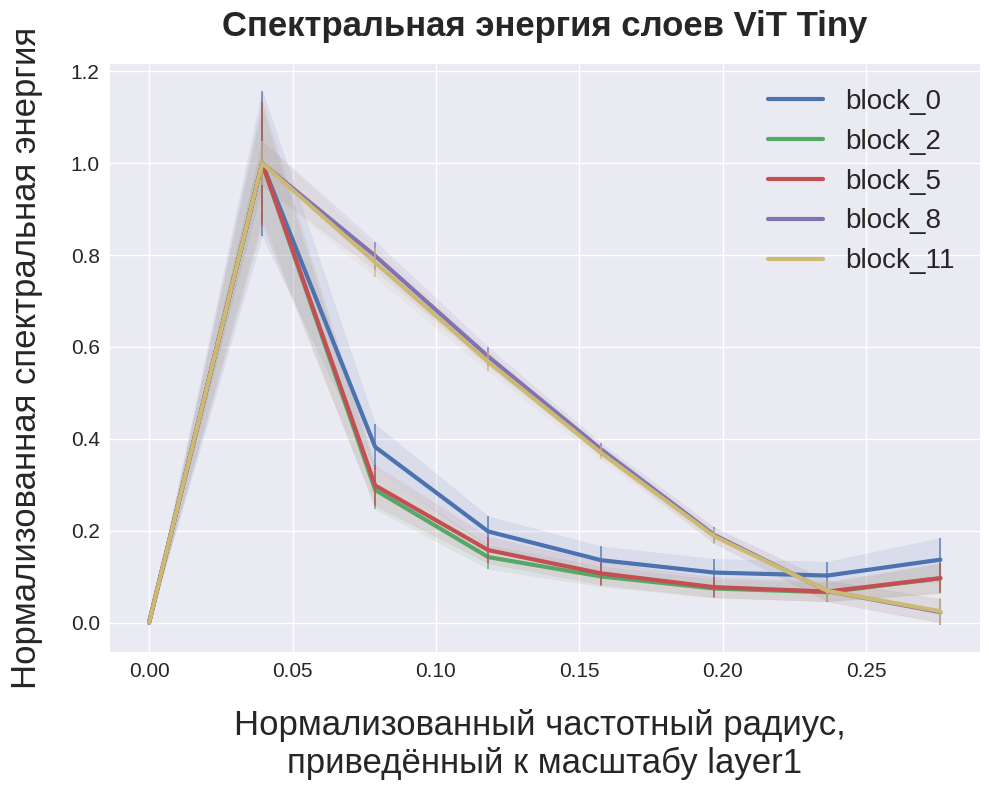

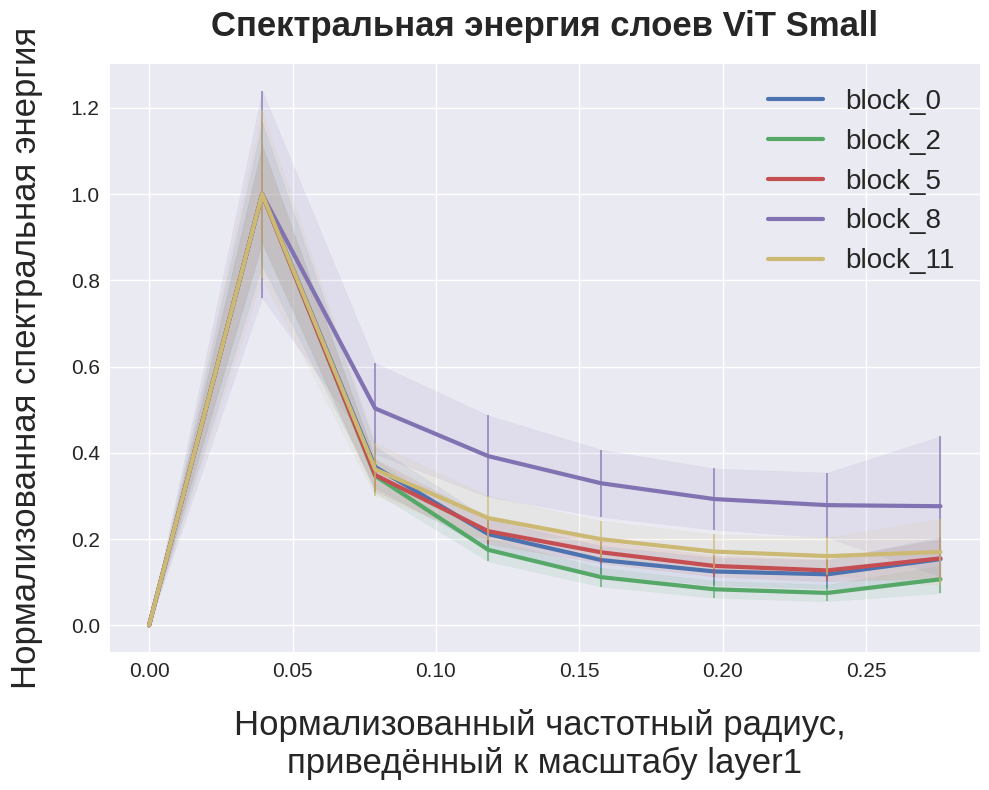

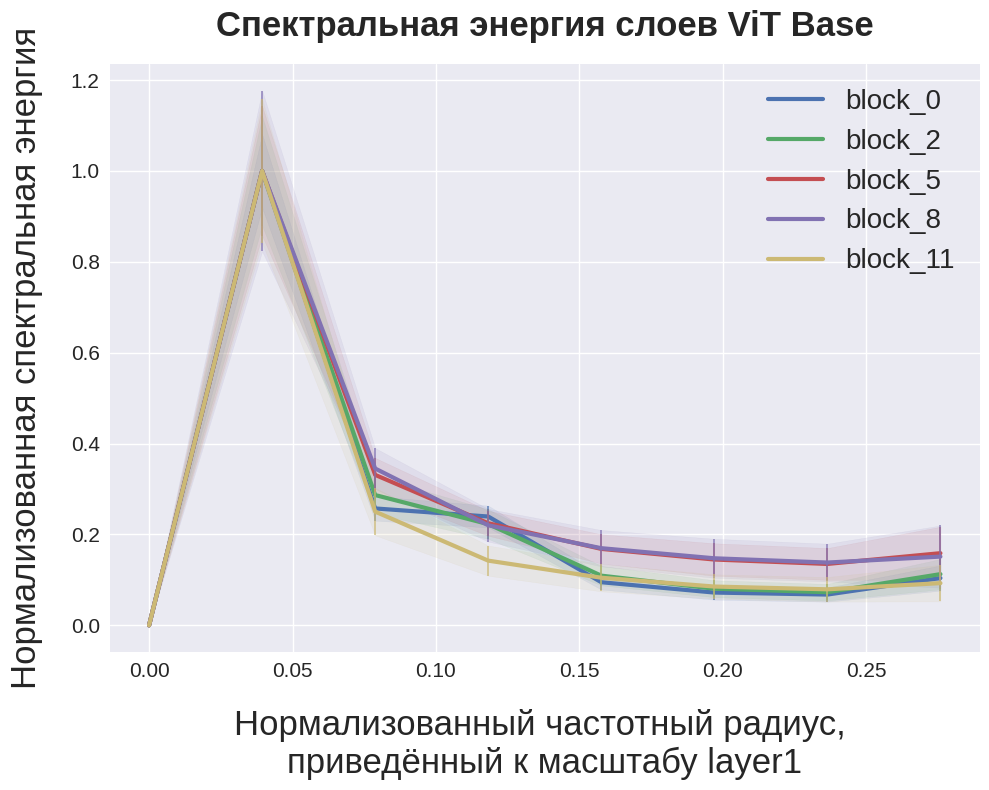

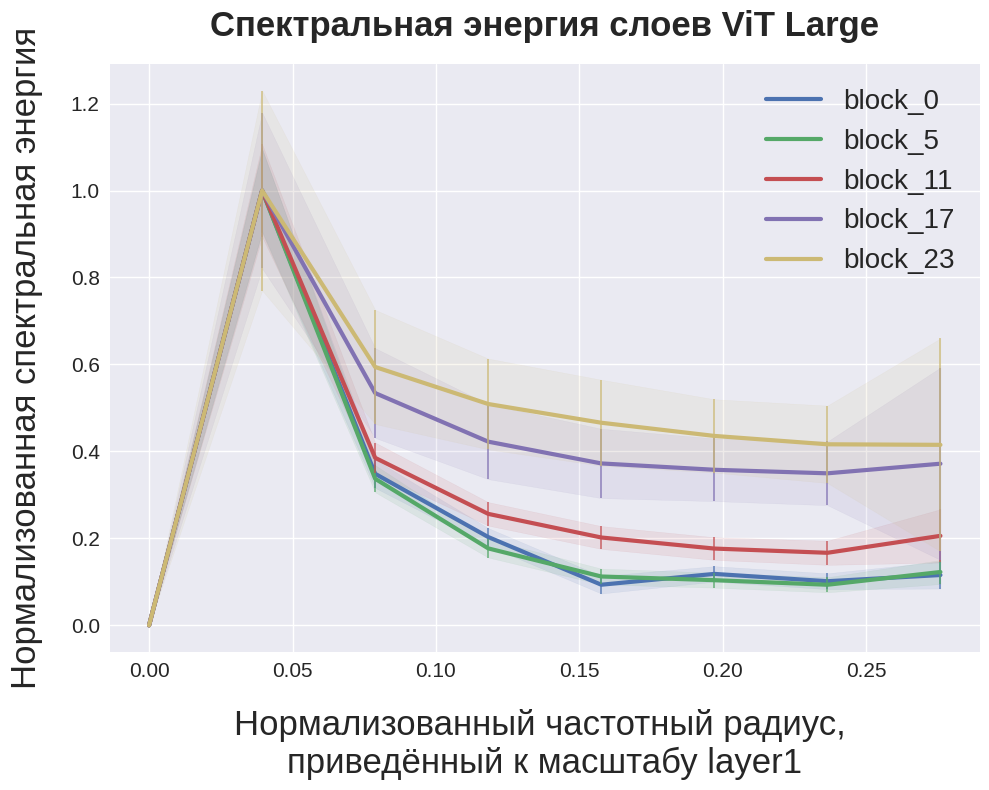

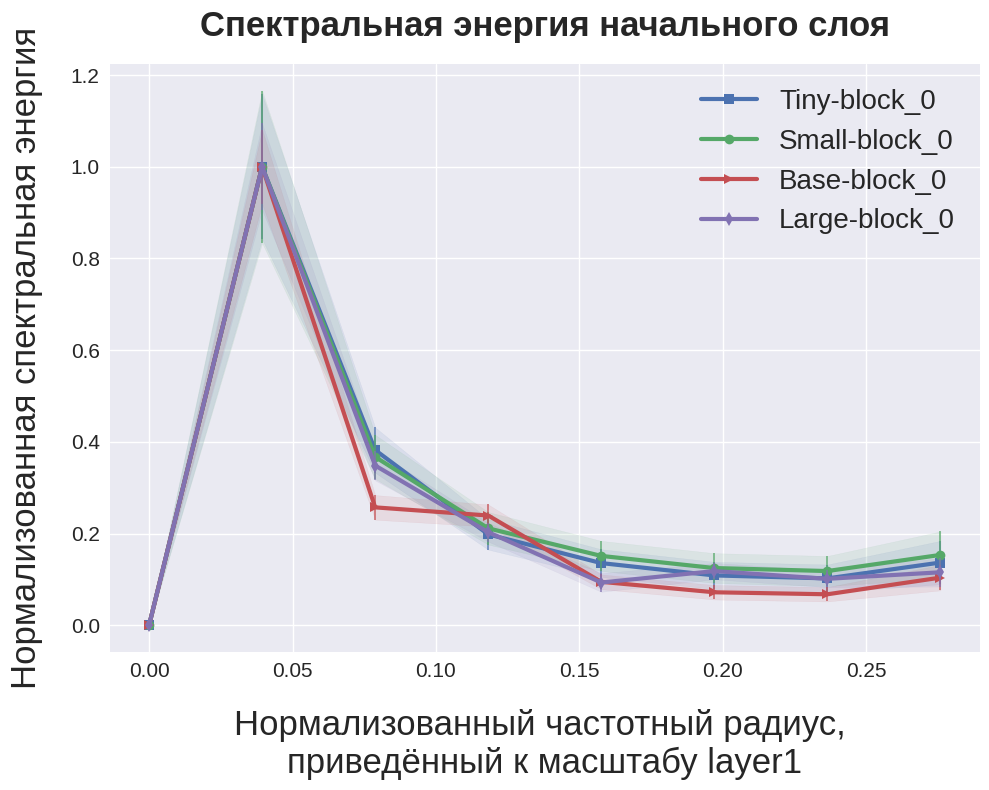

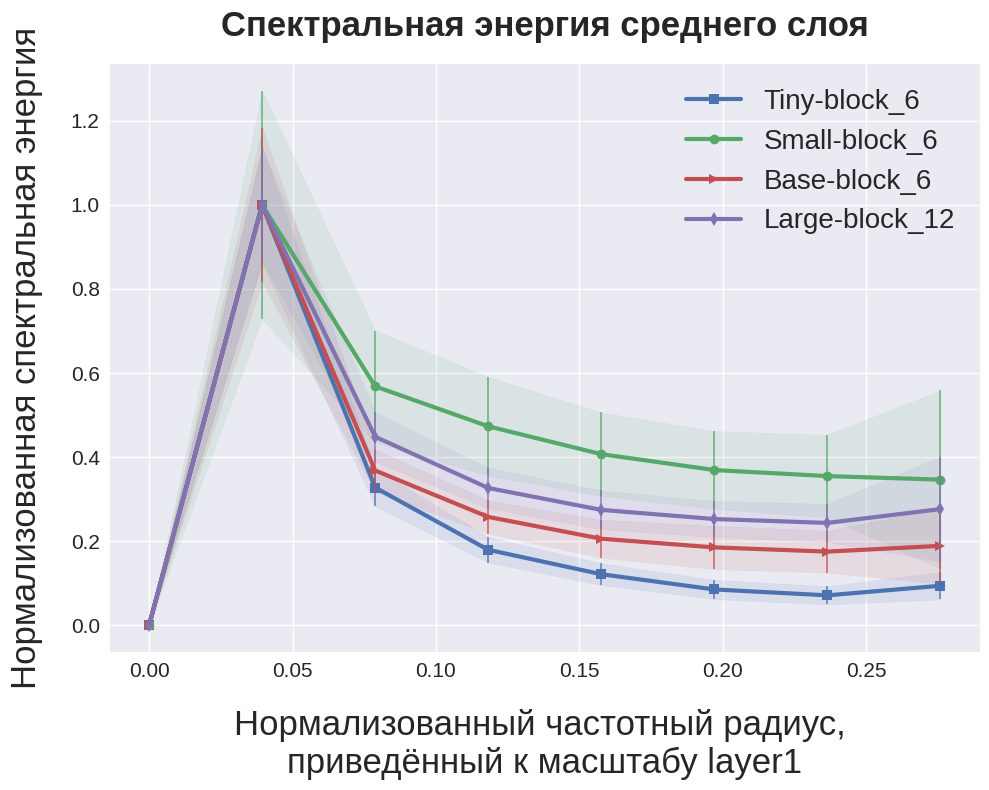

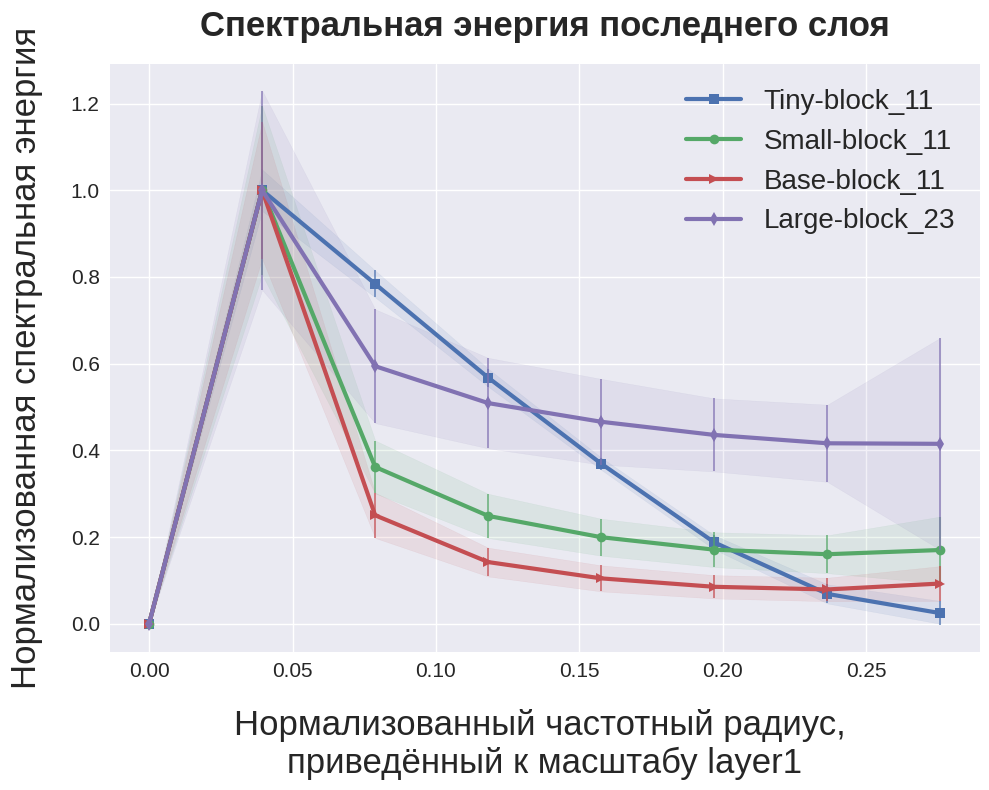

In [16]:
def select_5_layers(stats):
    layers = list(stats.keys())
    n = len(layers) - 1
    idxs = sorted(set([0, n//4, n//2, (3*n)//4, n]))
    return [layers[i] for i in idxs]

markers = {
    "Tiny": "s",
    "Small": "o",
    "Base": ">",
    "Large": "d",
}

# Для ViT графики приводим к масштабу layer1 ResNet.
# При новой методике это RESNET_LAYER1_REF_LEN=29 для входа 224x224.
for model_key, stats in all_vit_stats.items():
    plot_layers = select_5_layers(stats)
    plot_spectra_compare(
        f"ViT {model_key}",
        stats,
        plot_layers=plot_layers,
        ref_res=RESNET_LAYER1_REF_LEN,
        save_path=os.path.join(FIG_PATH, f"vit_{model_key.lower()}_spectra_layers.png")
    )

# Для межмасштабного сравнения также используем общий ref_res ResNet layer1.
plot_spectra_compare_in_layer(all_vit_stats, "начального", ref_res=RESNET_LAYER1_REF_LEN, save_path=os.path.join(FIG_PATH, "vit_begin_block.png"))
plot_spectra_compare_in_layer(all_vit_stats, "среднего", ref_res=RESNET_LAYER1_REF_LEN, save_path=os.path.join(FIG_PATH, "vit_middle_block.png"))
plot_spectra_compare_in_layer(all_vit_stats, "последнего", ref_res=RESNET_LAYER1_REF_LEN, save_path=os.path.join(FIG_PATH, "vit_last_block.png"))

## Выведение и сохранение значений метрик

In [12]:
all_metrics = []
for model_key, stats in all_vit_stats.items():
    layers = list(stats.keys())
    selected_layers = {
        "Начальные": layers[0],
        "Средние": layers[len(layers)//2],
        "Глубокие": layers[-1],
    }
    metrics_df = compute_metrics_table(
        stats,
        selected_layers=selected_layers,
        ref_len=RESNET_LAYER1_REF_LEN,
        architecture=f"ViT_{model_key}"
    )
    all_metrics.append(metrics_df)
    latex_df = save_metrics_tables(metrics_df, f"ViT {model_key}", f"vit_{model_key.lower()}")
    display(latex_df)

vit_metrics_all = pd.concat(all_metrics, ignore_index=True)
vit_metrics_all.to_csv(os.path.join(TABLE_PATH, "vit_all_metrics_long.csv"), index=False)
display(vit_metrics_all)

saved: zero/tables/vit_tiny_metrics_long.csv
saved: zero/tables/vit_tiny_metrics_latex_ready.csv
saved: zero/tables/vit_tiny_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ViT Tiny,Начальные,block_0,0.120 $\pm$ 0.011,61.504 $\pm$ 6.721,0.000 $\pm$ 0.000
1,ViT Tiny,Средние,block_6,0.113 $\pm$ 0.010,65.398 $\pm$ 6.092,0.000 $\pm$ 0.000
2,ViT Tiny,Глубокие,block_11,0.120 $\pm$ 0.004,62.825 $\pm$ 2.543,0.000 $\pm$ 0.000


saved: zero/tables/vit_small_metrics_long.csv
saved: zero/tables/vit_small_metrics_latex_ready.csv
saved: zero/tables/vit_small_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ViT Small,Начальные,block_0,0.125 $\pm$ 0.011,58.372 $\pm$ 6.707,0.000 $\pm$ 0.000
1,ViT Small,Средние,block_6,0.151 $\pm$ 0.011,41.622 $\pm$ 7.613,0.000 $\pm$ 0.000
2,ViT Small,Глубокие,block_11,0.134 $\pm$ 0.011,51.883 $\pm$ 6.576,0.000 $\pm$ 0.000


saved: zero/tables/vit_base_metrics_long.csv
saved: zero/tables/vit_base_metrics_latex_ready.csv
saved: zero/tables/vit_base_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ViT Base,Начальные,block_0,0.112 $\pm$ 0.007,68.622 $\pm$ 4.623,0.000 $\pm$ 0.000
1,ViT Base,Средние,block_6,0.136 $\pm$ 0.012,50.617 $\pm$ 7.516,0.000 $\pm$ 0.000
2,ViT Base,Глубокие,block_11,0.115 $\pm$ 0.013,63.035 $\pm$ 7.305,0.000 $\pm$ 0.000


saved: zero/tables/vit_large_metrics_long.csv
saved: zero/tables/vit_large_metrics_latex_ready.csv
saved: zero/tables/vit_large_metrics_latex.tex


,Модель,Уровень,Слой/блок,Центроид,"LowFrac, \%","HighFrac, \%"
0,ViT Large,Начальные,block_0,0.121 $\pm$ 0.007,62.107 $\pm$ 4.377,0.000 $\pm$ 0.000
1,ViT Large,Средние,block_12,0.145 $\pm$ 0.006,45.661 $\pm$ 4.296,0.000 $\pm$ 0.000
2,ViT Large,Глубокие,block_23,0.156 $\pm$ 0.007,38.613 $\pm$ 4.755,0.000 $\pm$ 0.000


,architecture,position,layer,resolution,freq_scale,centroid_mean,centroid_std,low_frac_mean,low_frac_std,high_frac_mean,high_frac_std,n
0,ViT_Tiny,Начальные,block_0,"(14, 14)",0.275862,0.120000,0.011091,0.615045,0.067211,0.0,0.0,320
1,ViT_Tiny,Средние,block_6,"(14, 14)",0.275862,0.112811,0.010387,0.653980,0.060920,0.0,0.0,320
2,ViT_Tiny,Глубокие,block_11,"(14, 14)",0.275862,0.120487,0.003628,0.628254,0.025428,0.0,0.0,320
3,ViT_Small,Начальные,block_0,"(14, 14)",0.275862,0.124586,0.011056,0.583723,0.067070,0.0,0.0,320
4,ViT_Small,Средние,block_6,"(14, 14)",0.275862,0.151256,0.011195,0.416216,0.076127,0.0,0.0,320
5,ViT_Small,Глубокие,block_11,"(14, 14)",0.275862,0.133985,0.010703,0.518833,0.065763,0.0,0.0,320
6,ViT_Base,Начальные,block_0,"(14, 14)",0.275862,0.111619,0.007264,0.686219,0.046235,0.0,0.0,320
7,ViT_Base,Средние,block_6,"(14, 14)",0.275862,0.136216,0.011906,0.506170,0.075163,0.0,0.0,320
8,ViT_Base,Глубокие,block_11,"(14, 14)",0.275862,0.114766,0.012631,0.630347,0.073054,0.0,0.0,320
9,ViT_Large,Начальные,block_0,"(14, 14)",0.275862,0.120664,0.006979,0.621075,0.043772,0.0,0.0,320


## Контрольный эксперимент ViT: фиксированное пространственное разрешение

In [13]:
# Для ViT downsampling между блоками отсутствует: все блоки работают на одной решётке патчей.
# Поэтому контроль здесь — таблица разрешений и метрик по выбранным блокам.
resolution_rows = []
for model_key, stats in all_vit_stats.items():
    layers = list(stats.keys())
    selected = [layers[0], layers[len(layers)//4], layers[len(layers)//2], layers[(3*len(layers))//4], layers[-1]]
    for layer in selected:
        resolution_rows.append({
            "model": model_key,
            "layer": layer,
            "resolution": str(stats[layer]["resolution"]),
            "radial_len": len(stats[layer]["rho"])
        })
vit_resolution_control = pd.DataFrame(resolution_rows)
vit_resolution_control.to_csv(os.path.join(TABLE_PATH, "vit_resolution_control.csv"), index=False)
with open(os.path.join(TABLE_PATH, "vit_resolution_control.tex"), "w", encoding="utf-8") as f:
    f.write(vit_resolution_control.to_latex(index=False, escape=False))
display(vit_resolution_control)

,model,layer,resolution,radial_len
0,Tiny,block_0,"(14, 14)",8
1,Tiny,block_3,"(14, 14)",8
2,Tiny,block_6,"(14, 14)",8
3,Tiny,block_9,"(14, 14)",8
4,Tiny,block_11,"(14, 14)",8
5,Small,block_0,"(14, 14)",8
6,Small,block_3,"(14, 14)",8
7,Small,block_6,"(14, 14)",8
8,Small,block_9,"(14, 14)",8
9,Small,block_11,"(14, 14)",8


## Загрузка уже сохранённых данных

In [14]:
# Пример:
# stats_vit_l = load_spectra_npz(os.path.join(SPECTRA_PATH, "vit_l_16_all_layers.npz"))
# plot_spectra_compare("ViT Large", stats_vit_l, plot_layers=select_5_layers(stats_vit_l), ref_res=RESNET_LAYER1_REF_LEN)